# 분류 모델
기계학습의 분류 모델은 주어진 입력 데이터를 미리 정의된 여러 개의 클래스(카테고리) 중 하나로 분류하는 작업을 수행한다.

분류 모델의 주요 목표는 입력 데이터의 특성을 학습하고, 이를 바탕으로 새로운 데이터가 들어왔을 때 해당 데이터를 올바른 클래스에 배정하는 것이다.

분류 모델은 종속 변수가 범주형일 때 주로 사용되며, 이항 분류(두 개의 클래스)와 다항 분류(세 개 이상의 클래스)를 다룰 수 있다.

**분류 알고리즘**
<table>
    <thead>
        <tr>
            <th>알고리즘</th>
            <th>설명</th>
            <th>특징</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>로지스틱 회귀 <code>sklearn.linear_model.LogisticRegression</code></td>
            <td>선형 회귀의 확장판으로, 종속 변수가 범주형일 때 사용됨.</td>
            <td>출력 값은 특정 클래스에 속할 확률로 해석됨.</td>
        </tr>
        <tr>
            <td>결정 트리 <code>sklearn.tree.DecisionTreeClassifier</code></td>
            <td>데이터의 속성에 따라 분할하여 학습하는 알고리즘으로, 트리 구조를 통해 분류함.</td>
            <td>이해하기 쉽고 해석이 용이함.</td>
        </tr>
        <tr>
            <td>서포트 벡터 머신 <code>sklearn.svm.SVC</code></td>
            <td>고차원 공간에서 데이터 포인트를 분리하는 초평면을 찾아내는 알고리즘임.</td>
            <td>데이터가 선형적으로 구분되지 않을 경우 커널 트릭을 사용함.</td>
        </tr>
        <tr>
            <td>k-최근접 이웃 <code>sklearn.neighbors.KNeighborsClassifier</code></td>
            <td>새로운 데이터 포인트가 주어지면 가장 가까운 k개의 이웃 데이터를 참고하여 분류함.</td>
            <td>계산 비용이 높고, 데이터의 크기에 민감함.</td>
        </tr>
        <tr>
            <td>나이브 베이즈 <code>sklearn.naive_bayes.GaussianNB</code></td>
            <td>베이즈 정리를 기반으로 하며, 모든 특징이 독립적이라는 가정하에 분류를 수행함.</td>
            <td>텍스트 분류에 자주 사용됨.</td>
        </tr>
        <tr>
            <td>랜덤 포레스트 <code>sklearn.ensemble.RandomForestClassifier</code></td>
            <td>여러 개의 결정 트리를 앙상블하여 예측 성능을 향상시키는 방법임.</td>
            <td>과적합을 방지하고 안정적인 예측을 제공함.</td>
        </tr>
        <tr>
            <td>그래디언트 부스팅 <code>sklearn.ensemble.GradientBoostingClassifier</code></td>
            <td>여러 개의 약한 학습기(주로 결정 트리)를 순차적으로 학습하여 강한 예측 모델을 만듭니다.</td>
            <td>XGBoost, LightGBM 등이 대표적임.</td>
        </tr>
        <tr>
            <td>가우시안 혼합 모델 <code>sklearn.mixture.GaussianMixture</code></td>
            <td>데이터가 여러 개의 가우시안 분포로 구성되어 있다고 가정하고, EM 알고리즘을 사용하여 파라미터를 추정함.</td>
            <td>주로 군집화에 사용됨.</td>
        </tr>
        <tr>
            <td>신경망 <code>sklearn.neural_network.MLPClassifier</code></td>
            <td>여러 개의 은닉층을 가지는 다층 퍼셉트론(Multilayer Perceptron, MLP) 등의 구조로, 비선형 문제를 해결하는 데 강력함.</td>
            <td>딥러닝의 기초가 됨.</td>
        </tr>
    </tbody>
</table>


# LogisticRegression(로지스틱 회귀)
- 이름만 회기이고 실제로는 분류 모델임.
- 회귀와 Logistic함수(sigmoid)를 통해서 분류예측하는 모델
- 이진/다중분류 모두 지원


## 이진분류
양성클래스를 예측하는 모델
1. 양성클래스에 대한 회귀식(회귀계수) 계산
2. 확률값 변환(sigmoid함수)
3. 1 - 양성클래스 확률값을 통해 음성클래스에 대한 확률 계산


### 로지스틱 함수 (Logistic Function) - 시그모이드 함수

**선형 방정식의 출력을 확률로 변환**해준다.
이 함수는 0과 1 사이의 값을 반환하여 분류 문제에서 이진 분류에 적합하다.

**시그모이드 함수 정의**

$
h(z) = \frac{1}{1 + e^{-z}}
$

여기서 $ z $는 입력값으로, 선형 방정식의 결과물이다.

![](https://d.pr/i/tTdKdt+)

**시그모이드 함수의 특징**
- 출력 값은 항상 0과 1 사이이다.
- $ z \to \infty $ 일 때, $ h(z) \to 1 $
- $ z \to -\infty $ 일 때, $ h(z) \to 0 $

**역할**
- **로지스틱 회귀**에서는 선형 결합을 시그모이드 함수에 넣어 0과 1 사이의 값을 얻고, 이를 확률로 해석.
- 이 값을 기준으로, 분류 문제에서 **0.5** 이상이면 클래스 1로, 그 미만이면 클래스 0으로 분류한다.

**정리**
1. 선형회귀 결과값(z) 계산
2. 시그모이드 함수에 z를 넣어 양성에 대한 확률값 계산
4. 0일때 확률도 마저 계산
3. 0.5를 기준으로 이진분류(0, 1) 수행


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# StandardScaler/MinMaxScaler: feature의 숫자 범위를 맞출 때 사용함.
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# LogisticRegression: 확률 기반 분류 모델을 만들 때 사용함.
from sklearn.linear_model import LogisticRegression

# classification_report: 분류 성능을 precision, recall, f1-score로 요약할 때 사용함.
from sklearn.metrics import classification_report

# class_weight: 클래스 불균형 데이터에서 클래스별 가중치를 계산할 때 사용함.
from sklearn.utils import class_weight


## 시그모이드 함수 생성 및 시각화


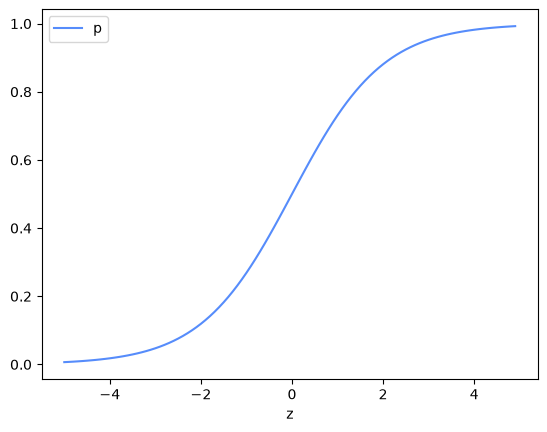

In [2]:
# 시그모이드 함수
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.arange(-5, 5, 0.1)
p = sigmoid(z) # 0 ~ 1사이의 확률값

df = pd.DataFrame({
    'z': z,
    'p': p
})
df.plot(x='z', y='p')
plt.show()

# 로지스틱 회귀를 이용한 생선 이진분류(fish.csv)

## 데이터 로드

In [3]:
fish_df = pd.read_csv('data/fish.csv')
fish_df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [4]:
is_bream_or_smelt = (fish_df['Species'] == 'Bream') | (fish_df['Species'] == 'Smelt')
fish_df = fish_df[is_bream_or_smelt]
fish_df['Species'].value_counts()

# fish_df == 도미, 빙어 데이터만 저장된 데이터프레임

Species
Bream    35
Smelt    14
Name: count, dtype: int64

## 데이터 스케일링
- StandardScaler: 평균 0, 표준편차 1 기준으로 수치 feature의 단위를 맞춤.

In [5]:
# Species 제거하여 수치 데이터만 남김
X = fish_df.drop('Species', axis=1).to_numpy()

# 종 이름만 남김
y = fish_df['Species'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y # 학습/테스트 데이터 분할 시 도미/빙어 비율을 똑같이 맞추는 옵션
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Accuracy 정확도

- Accuracy는 분류 모델이 전체 데이터 중 몇 개를 맞혔는지 나타내는 가장 기본적인 평가 지표임.
- 계산식은 `맞힌 개수 / 전체 데이터 개수`임.
- 예를 들어 평가 데이터 100개 중 80개를 맞히면 accuracy는 `0.8`, 즉 80%임.
- scikit-learn의 분류 모델에서 `score(X, y)`는 기본적으로 accuracy를 반환함.
- 학습셋 accuracy는 모델이 훈련 데이터에 얼마나 잘 맞았는지, 평가셋 accuracy는 처음 보는 데이터에 얼마나 잘 맞는지 확인하는 값임.

### 해석할 때 주의할 점

- 클래스 비율이 비슷한 데이터에서는 accuracy가 직관적임.
- 하지만 특정 클래스가 압도적으로 많은 불균형 데이터에서는 accuracy만으로 모델을 판단하면 위험함.
- 예를 들어 대부분의 정답이 `5`라면 모델이 계속 `5`만 예측해도 accuracy가 어느 정도 높게 나올 수 있음.
- 그래서 불균형 데이터에서는 `classification_report()`로 precision, recall, f1-score를 함께 확인함.



## 로지스틱 회귀 모델 생성 및 학습, 평가

- LogisticRegression: 확률 점수를 기준으로 클래스를 분류하는 선형 분류 모델임.


In [6]:
lr_clf = LogisticRegression()

# 학습
lr_clf.fit(X_train_scaled, y_train)

# 평가
print("학습셋 : ", lr_clf.score(X_train_scaled, y_train))
print("평가셋 : ", lr_clf.score(X_test_scaled, y_test))

학습셋 :  1.0
평가셋 :  1.0


## 학습된 모델로 예측값을 만들고 결과를 확인

- predict_proba: 각 클래스에 속할 확률을 반환하는 메서드.

---

- 로지스틱 회귀는 먼저 선형 회귀식처럼 z 값을 계산함
    - z = w1*x1 + w2*x2 + ... + b

In [7]:
# 확률값(p) : 입력값에 따른 정답의 종류
print("확률값:", lr_clf.classes_)

# 예측(predict)
y_pred = lr_clf.predict(X_test_scaled[:3])
# print(X_test_scaled[:3])
print(y_pred)

# predict_proba(): 각 클래스(['Bream' 'Smelt']) 에 속할 확률
y_pred_proba = lr_clf.predict_proba(X_test_scaled[:3])
print(y_pred_proba)

# 학습된 회귀 계수(w1), 절편(w0)
print("coef: ", lr_clf.coef_) # 회귀계수
print("intercept: ", lr_clf.intercept_) # 절편

# 회귀식 결과값(z)
z = lr_clf.decision_function(X_test_scaled[:3])
z = lr_clf.coef_ @ X_test_scaled[:3].T + lr_clf.intercept_
print("회귀식 결과값(z): ", z)

print("양성 확률값: ", sigmoid(z))
print("음성 확률값: ", 1 - sigmoid(z))


확률값: ['Bream' 'Smelt']
['Bream' 'Bream' 'Smelt']
[[0.99096543 0.00903457]
 [0.99432217 0.00567783]
 [0.04998825 0.95001175]]
coef:  [[-0.57089591 -0.80002209 -0.83364179 -0.86805125 -0.81749383]]
intercept:  [-2.68396424]
회귀식 결과값(z):  [[-4.69762116 -5.16549188  2.94468638]]
양성 확률값:  [[0.00903457 0.00567783 0.95001175]]
음성 확률값:  [[0.99096543 0.99432217 0.04998825]]


## 다중분류


### softmax 함수

**소프트맥스 함수**

**다중 클래스 분류**를 위한 활성화 함수로, 각 클래스에 대한 확률을 반환한다.

Logistic regression의 softmax 함수는 다중 클래스 분류 문제에서 사용되는 확률적 모델이다.

이 함수는 입력된 각 클래스에 대한 점수를 확률로 변환하여, 전체 클래스 중 하나를 예측할 수 있게 한다.

**Softmax 함수 개념:**

Softmax 함수는 $K$개의 클래스를 가정했을 때, 주어진 입력 데이터에 대해 각 클래스의 확률을 다음과 같이 계산한다:

$$
softmax(z_i) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

- $z_k$: 각 클래스에 대한 점수(입력 값)
- $e^{z_k}$: 해당 점수에 대해 지수 함수 적용
- $\sum_{j=1}^{K} e^{z_j}$: 모든 클래스 점수에 대해 지수 함수 적용 후의 총합
Softmax 함수는 **여러 개의 값을 확률로 변환**하는 함수다. 이 함수는 각 값을 비교하여 상대적으로 **더 큰 값일수록 더 높은 확률**을 할당하는 방식으로 작동한다.

**설명**

1. **입력 값들**: Softmax 함수는 여러 숫자를 입력으로 받는다. 예를 들어, `[2.0, 1.0, 0.1]`이라는 세 개의 값을 받았다고 하자.
2. **지수 함수 적용**: 각 숫자에 대해 지수 함수 $e^x$를 적용한다. 이는 숫자를 양수로 변환하고, 값이 클수록 더 큰 값으로 변환한다.
    - $e^{2.0} \approx 7.39$
    - $e^{1.0} \approx 2.72$
    - $e^{0.1} \approx 1.11$

3. **모든 값을 더하기**: 이렇게 변환된 값들을 모두 더한다. 이 값이 나중에 분모가 된다.
    - $7.39 + 2.72 + 1.11 = 11.22$

4. **각 값을 나누기**: 이제 각 값을 이 총합으로 나눠서 **각 값의 비율을 구한다**. 이 값들이 각 값에 대응하는 확률이다.
    - 첫 번째 값: $\frac{7.39}{11.22} \approx 0.659$ → 약 65.9% 확률
    - 두 번째 값: $\frac{2.72}{11.22} \approx 0.242$ → 약 24.2% 확률
    - 세 번째 값: $\frac{1.11}{11.22} \approx 0.099$ → 약 9.9% 확률

**아주 쉽게 정리하자면**
1. 숫자를 e의 지수로 적용해서 아주 크게 만들고(차이가 도드러지도록),
2. 그 숫자들의 총합을 구한 후,
3. 각 숫자를 총합으로 나누어서 확률로 만듦.


## Softmax 함수 생성 및 확인

- np.exp(x): 자연상수 e를 밑으로 하는 지수 함수 (e^x)
- 자연 상수 e: 약 2.71828

In [8]:
def softmax(z):
    exp_z = np.exp(z - np.max(z)) # 지수식 안정화
    return exp_z / exp_z.sum(axis=1, keepdims=True) # keepdims=True 연산후 차원유지

z = np.array([[2, 1, 0.1], [1, 3, 2.5]])
p = softmax(z)
print(p)
pred = np.argmax(p, axis=1)
print(pred)


[[0.65900114 0.24243297 0.09856589]
 [0.07769558 0.57409699 0.34820743]]
[0 1]


## 다중 분류용 데이터 준비 및 스케일링


In [9]:
fish_df = pd.read_csv('data/fish.csv')

X = fish_df.drop('Species', axis=1).to_numpy()
y = fish_df['Species'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 로지스틱 회귀 모델 학습 및 평가

- LogisticRegression: 확률 점수를 기준으로 클래스를 분류하는 선형 분류 모델임.

In [10]:
lr_clf = LogisticRegression()

lr_clf.fit(X_train_scaled, y_train)

print("학습셋: ", lr_clf.score(X_train_scaled, y_train))
print("평가셋: ", lr_clf.score(X_test_scaled, y_test))

학습셋:  0.8188976377952756
평가셋:  0.8125


## 모델 예측

- predict_proba: 각 클래스에 속할 확률을 반환하는 메서드임.
- predict: 학습된 모델로 새 데이터의 예측값을 생성하는 메서드임.


In [11]:
# 확률값(p)
print(lr_clf.classes_)

# 예측 - predict()
y_pred = lr_clf.predict(X_test_scaled[-3:])
print("예측값: ", y_pred)

# 클래스 확률 - predict_proba()
y_pred_proba = lr_clf.predict_proba(X_test_scaled[-3:])
# print("확률값: ", y_pred_proba)


# 회귀식의 결과값
z = lr_clf.decision_function(X_test_scaled[-3:])
print("z: ", z)
print("확률값: ", softmax(z))
print("예측값: ", np.argmax(softmax(z), axis=1))

y_pred_proba


['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
예측값:  ['Perch' 'Pike' 'Bream']
z:  [[ -2.35709744   0.54199811   2.30729031  -1.39314529   1.69328001
    0.20159319  -0.99391889]
 [  2.46954858  -7.4077349    5.93470504   9.62838909  -1.30534642
  -14.02522618   4.7056648 ]
 [  5.69212561   0.96196723   1.02383749  -0.34013093   0.1187083
   -9.43649916   1.97999145]]
확률값:  [[4.94738523e-03 8.98332117e-02 5.24920568e-01 1.29722357e-02
  2.84074534e-01 6.39147290e-02 1.93373362e-02]
 [7.53136240e-04 3.86566164e-08 2.40863990e-02 9.68096114e-01
  1.72765682e-05 5.16754049e-11 7.04703588e-03]
 [9.53437395e-01 8.41415480e-03 8.95118247e-03 2.28831841e-03
  3.62066045e-03 2.56456627e-07 2.32880325e-02]]
예측값:  [2 3 0]


array([[4.94738523e-03, 8.98332117e-02, 5.24920568e-01, 1.29722357e-02,
        2.84074534e-01, 6.39147290e-02, 1.93373362e-02],
       [7.53136240e-04, 3.86566164e-08, 2.40863990e-02, 9.68096114e-01,
        1.72765682e-05, 5.16754049e-11, 7.04703588e-03],
       [9.53437395e-01, 8.41415480e-03, 8.95118247e-03, 2.28831841e-03,
        3.62066045e-03, 2.56456627e-07, 2.32880325e-02]])

## Wine Quality 다중분류(winequality-red.csv)


## Wine Quality 다중분류 평가 해석

- Wine Quality 데이터의 `quality`는 `3, 4, 5, 6, 7, 8`처럼 여러 클래스를 가진 다중분류 target임.
- 이 데이터는 `5`, `6` 품질이 대부분이고 `3`, `8` 품질은 매우 적어서 클래스 불균형이 있음.
- `model.score(X_test, y_test)`는 평가 데이터 accuracy를 반환함. 즉, 전체 와인 중 품질 등급을 정확히 맞힌 비율임.
- `class_weight='balanced'` 또는 직접 계산한 클래스 가중치를 사용하면 적은 클래스도 더 맞추려 하기 때문에 전체 accuracy는 낮아질 수 있음.
- 따라서 이 실습에서는 accuracy와 함께 `classification_report()`의 precision, recall, f1-score를 같이 확인함.



## 데이터 로드


In [12]:
wine_df = pd.read_csv('data/winequality-red.csv')
print(wine_df['quality'].value_counts())
wine_df

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## 데이터 스케일링

- MinMaxScaler: 최소값 0, 최대값 1 범위로 수치 feature의 범위를 맞춤.
- LogisticRegression: 확률 점수를 기준으로 클래스를 분류하는 선형 분류 모델임.
- classification_report: precision, recall, f1-score를 한 번에 요약해 보여줌.
- score: 분류 모델에서는 accuracy를 반환함. 전체 샘플 중 정답을 맞힌 비율임.


In [13]:
from sklearn.utils import class_weight
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

X = wine_df.drop('quality', axis=1).to_numpy()
y = wine_df['quality'].to_numpy() # [3, 4, 5, 6, 7, 8]

# train_test_split(): 데이터를 학습용/평가용으로 나누는 함수. test_size는 평가 비율, random_state는 재현용 난수 고정값임.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, stratify=y)

# MinMaxScaler(): 최소값 0, 최대값 1 범위로 수치 feature를 맞춤.
scaler = MinMaxScaler()

# fit_transform(): 기준 학습과 변환을 한 번에 수행함. 훈련 데이터에만 사용하는 것이 안전함.
X_train = scaler.fit_transform(X_train)
# transform(): fit에서 배운 기준으로 데이터를 변환함. 평가 데이터에는 fit하지 않는 것.
X_test = scaler.transform(X_test)

# 클래스별 가중치 계산
weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y), y=y)
class_weights = dict(zip(np.unique(y), weights))
print("클래스 가중치:", class_weights)

# LogisticRegression(): 확률 점수를 기준으로 클래스를 분류하는 선형 분류 모델임. C는 규제 강도, max_iter는 반복 학습 상한임.
model = LogisticRegression(class_weight=class_weights)
# fit(): 훈련 데이터에서 모델 또는 전처리 기준을 학습함.
model.fit(X_train, y_train)

print('학습셋: ', model.score(X_train, y_train))
print('평가셋: ', model.score(X_test, y_test))

# predict(): 학습된 모델로 새 데이터의 예측값을 생성함.
print(classification_report(y_test, model.predict(X_test)))

# precision: 모델이 해당 클래스로 예측한 것 중 실제로 맞은 비율
# recall :  실제 해당 클래스인 것 중 모델이 찾아낸 비율  (맞게 찾은 개수 / 실제 정답 개수)
# f1-score :  precision, recall을 함께 반영한 점수
# support :  실제 데이터상 해당 클래스가 몇 개 있었는지

print(model.predict(X_test[:5]))
print(y_test[:5])

클래스 가중치: {np.int64(3): np.float64(26.65), np.int64(4): np.float64(5.028301886792453), np.int64(5): np.float64(0.39133627019089573), np.int64(6): np.float64(0.4177115987460815), np.int64(7): np.float64(1.3391959798994975), np.int64(8): np.float64(14.805555555555555)}
학습셋:  0.41282251759186867
평가셋:  0.34375
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.05      0.18      0.08        11
           5       0.65      0.50      0.57       136
           6       0.56      0.20      0.29       128
           7       0.27      0.38      0.31        40
           8       0.00      0.00      0.00         3

    accuracy                           0.34       320
   macro avg       0.25      0.21      0.21       320
weighted avg       0.54      0.34      0.40       320

[7 3 5 6 6]
[6 5 5 5 6]


# 로지스틱 모델 정리
- 로지스틱은 **분류 모델** 이다(단, 내부에 선형 모델을 품고 있음)

- X,y를 확습하면 내부적으로 선형 방정식 z = w0 + w1x 의 계수가 설정된다.

- z를 얻은 이후 내부에 포함된 시그모이드 함수를 통과시켜 0~1사이 곡선(확률)을 만든다

- 이후 모델에 입력 값이 들어오면 학습된 식(선형 방정식 + 시그모이드)을 이용해 확률을 만든다
    - 다중 분류인 경우에는 (선형 방정식 + softmax)를 이용해 확률을 만든다

- LogisticRegression.predict() : 입력된 값에 해당하는 클래스(예측 결과)를 반환
    - 이진 분류: 입력값을 모델에 통과시켜 얻은 확률을 0.5를 기준으로 0/1로 나누어 알맞은 클래스를 반환
    - 다중 분류: 입력값을 모델에 통과시켜 클래스별 확률을 체크해 가장 확률이 높은 클래스를 반환

- LogisticRegression.predict_proba() : 입력된 값에 따라 클래스가 될 확률(0~1) 자체를 반환